**ВАЖНО!**

_Если используется настройка VS Code_

```
"jupyter.notebookFileRoot": "${workspaceFolder}"
```

Ничего делать не нужно. Можно просто запустить ячейки.

_Если нет_

Путь ноутбука находится по адресу: '\<project\>/examples/\<notebook\>.ipynb' - Раскомментируйте ниже ячейку - она сместит cwd на уровень выше. Все пути будут работать корректно.


In [ ]:
# import os
# os.chdir('..')

# Условия

Приведены условия выполнения задания и логичный способ решения.

1. _**Дан датасет молекул для оценки.**_

   Все молекулы приведены в формате SDF в 2D представлении. Значит, можно использовать напрямую SMILES без необходимости учитывать стереохимию (ярко видно на примере 27 из датасета)

2. _**Нужно использовать `aizynthfinder` для работы**_

   Движка есть проблема - его сложно распараллелить из-за внутренней структуры. А так как нужно настроить именно его, будет проще скопировать структуры, и сделать параллельно работающий инструмент. (Для этих целей возможно лучше использовать `MultiAiZ`)

3. _**Найти числовую функцию синтетической сложности и вычислить её на датасете.**_

   Так как некоторые молекулы могут не иметь синтетического пути, функция должна учитывать этот факт и не обнулять значение в таком случае. Очевидно, нужно учитывать не только сложность пути и количество узлов, но и стоимость прекурсоров.

   Логично использовать уже готовые метрики, которые были провалидированы на реальных датасетах и имеют оценку экспертов.

4. _**Не указаны: база данных, стоимость доступных реагентов, предпочтительные реакции**_

   Без этой информации можно использовать стандартный набор реагентов с их стоимостью. Например, тот, который скачивается вместе с библиотекой `aizynthfinder` (модели фильтрации и поиска пути, обученные на `UPSTO` базе данных реакций, `ZINC` - база прекурсоров).

   Исходя из этого, можно напрямую использовать стороннюю метрику, которая использует `aizynthfinder` в качестве отправной точки.

   Нельзя использовать скорринг-функции, которые основаны на внешних датасетах. Если будет использоваться внутренняя база прекурсоров, в ней, скорее всего, уже будут включены цены. Поэтому не имеет смысла оценивать цены прекурсоров.

5. _**Нужны данные о скорости расчёта.**_

   Молекул много, значит нужно использовать параллельные вычисления. Нужно логирование или хотя бы сохранение времени расчёта для каждой отдельной молекулы.


# Импорты

Обертка для ретросинтеза импортируется как набор модулей для отдельных задач:

- `parameters` - настройки движка
- `scores` - набор доступных скорринговых функций
- `draw` - инструменты для отчётов, рисования и так далее.
- `analyze` - инструменты для анализа маршрутов
- `retro` - основные функции ретросинтеза.


In [2]:
import os

In [ ]:

os.getcwd()

'e:\\GitHub'

In [4]:
os.path.abspath('__file__')

'e:\\GitHub\\ChemRAR\\__file__'

In [2]:
from __future__ import annotations

from rdkit import Chem as rd
from chemrar_retro import parameters , retro, scores, draw,analyze
from pathlib import Path
import pandas as pd
import numpy as np
from typing import Any, Callable
import matplotlib.pyplot as plt

# Загрузка молекул датасета.


In [2]:
mols = retro.mols_from_sdf(Path('data/output_500.sdf'))

# Настройка движка и функций скоринга


**Доступность**

Нужно оценить доступность прекурсоров в банке веществ.

- `NPrecursors` - `NStockPrecursors`

  Сток один, поэтому можно грубо оценить, cколько прекурсоров есть в банке веществ.

  Чтобы учесть не только долю, но и абсолютное количество (так как абсолютное количество показывает и сложность реакции), можно использовать разницу между общим количеством прекурсоров и доступных прекурсоров.

  (Для нескольких стоков логично использовать `NSourcePrecursors` c указанием качества источников или цены)

**Маршрут**

Так как нет внешнего файла с предпочтительными классами реакций, по умолчанию все классы реакций равнозначны.

- `NReactions`

  Основной показатель, который характеризует длину маршрута.

- `TemplateOccurrence`

  Оценивает частоту встречаемости данных реакций. Чем выше частота, тем проще реакция.

**Сложность молекулы**

- `SCScore`

  Характеризует сложность молекулы, отражает реальный синтетический путь. Нужно дообучать на своей базе данных.

**Цена**

Цены точно требуют своей базы данных.

**Оценка молекул без маршрута.**

Если путь не найден, метрики, оценивающие маршрут или стоимость прокурсоров, будут давать странный результат.

- `SCScore`

- `BR-SAScore`

  Требуется обучить на своём наборе реакций, Но в оригинальной статье использовался aizynthfinder со стандартным стоком и фильтрами. Сравнивалась эффективность и скорость работы с другими метриками. К тому же она очень быстрая. [Статья](https://link.springer.com/article/10.1186/s13321-024-00879-0)

  Хорошо оценивает медицинские молекулы. Даже если синтетический путь не найден, высокое значение этой метрики может свидетельствовать о том, что молекула полезна и стоит перестроить модель ретросинтеза. Исходный набор данных содержит достаточно много молекул с большим количеством циклов, что свидетельствует о том, что молекулы могут использоваться как биологически активные. Имеет смысл использовать с меньшим весом, нежели _SCScore_

**Не вошли в рассмотрение**

- `FSscore`

  Можно дообучить на своём стоке и наборе реакций, но для этого требуется целая инфраструктура разметки. А также адаптация под сборку оригинального проекта.

- `RAScore`

  Использует старую версию python=3.7 - требуется адаптация всех пакетов и проверка работы


Можно использовать масштабаторы для этой оценки, но можно масштабирование встроить и в саму функцию.

Чтобы записать вместе характеристики, нужно привести диапазоны к единому:

- **TemplateOccurrence (TO)** [0,1] - уже масштабировано
- **NPrecursors (NP), NStockPrecursors (NSP)** [1,inf) - обычно требуется от 3-10 => используем сигмойду
- **NReactions (NR)** [0,inf) - обычно требуется от 1-8 => используем сигмойду
- **BR-SAScore (SAS)** [0,1] - специально масштабированная в классе скорера

Итоговая формула (0 - плохо, 1 - отлично):
$$NP-NSP$$


In [ ]:
def sigmoid(x:float|np.ndarray,*,scale:float, slope:float,x0:float, y0:float,):
    return scale / (1 + np.exp(-slope * (x - x0))) - y0

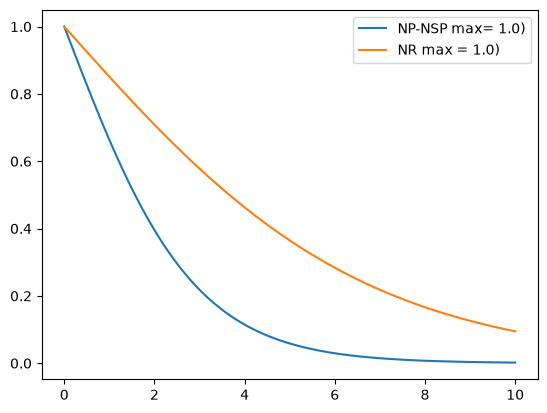

In [ ]:
x = np.linspace(0,10, 101)

slope =-0.5
x0=0
y0=0

y_missing = sigmoid(x, scale=2,slope=-0.7, x0=0,y0=0 )
y_reactions = sigmoid(x, scale=2,slope=-0.3, x0=0,y0=0 )

plt.plot(x,y_missing, label=f'NP-NSP max= {max(y_missing)})')
plt.plot(x,y_reactions, label=f'NR max = {max(y_reactions)})')
plt.legend()

In [ ]:
y = sigmoid(x, scale=1,slope=-1, x0=4,y0=0 )

In [ ]:



class SyntheticScorer(parameters.BaseScorer):


    def __init__(self, config: parameters.Configuration, scaler_params: dict[str, Any] | None = None) -> None:


        # Incorrect typings in aizynthfinder
        self.s_total:Callable[...,float] = scores.availability.NPrecursors( ).create_scorer(config) # type: ignore
        self.s_stock:Callable[...,float] = scores.availability.NStockPrecursors().create_scorer(config) # type: ignore

        self.s_templ:Callable[...,float] = scores.reaction.TemplateOccurrence().create_scorer(config) # type: ignore
        self.s_reactions:Callable[...,float] = scores.reaction.NReactions().create_scorer(config) # type: ignore

        self.s_scs:Callable[...,float] =scores.synthetic.SCScore(sc_score_model='data/scscore/model.ckpt-10654.as_numpy.pickle').create_scorer(config) # type: ignore


        super().__init__(config, scaler_params)

    def _score_node(self, node: parameters.MctsNode) -> float:

        self.s_total(node) - self.s_stock(node)
        pass

    def _score_reaction_tree(self, tree: parameters.ReactionTree) -> float:
        if not tree.is_solved:1


        pass


class SyntheticScore(parameters.Score):
    scorer_type=SyntheticScorer


tree_scorer =SyntheticScore()

In [ ]:
engine = retro.create_engine(
    expansion_policies=dict(
        uspto=parameters.ExpansionPolicy(
            model=Path("download/example/uspto_model.onnx"),
            template=Path("download/example/uspto_templates.csv.gz"),
        ),
        ringbreaker=parameters.ExpansionPolicy(
            model=Path("download/example/uspto_ringbreaker_model.onnx"),
            template=Path("download/example/uspto_ringbreaker_templates.csv.gz"),
        ),
    ),
    filters=dict(
        uspto=parameters.FilterPolicy(model=Path("download/example/uspto_filter_model.onnx")),
    ),
    stock=dict(
        zinc=parameters.Stock(path=Path("download/example/zinc_stock.hdf5")),
    ),
    scores=[(scorers.availability. FractionInStockScorer, {})],
)


# Ретросинтез


In [ ]:
engine_selected = retro.select(
    engine,
    stocks=engine.stock.items,
    filter_policies=engine.filter_policy.items,
    search_scorers={"state score": 1},
    expansion_policies=engine.expansion_policy.items,
)

In [ ]:
tree = retro.generate_tree(engine_selected, smiles)
retro.search_tree(tree, 100)
result = analyze.analyze_tree(tree, scorers=["fraction in stock", "state score"], top_n=10)